# TS-SatFire -- Active Fire Detection -- HybridAFNet v2 -- Inference

This notebook loads the best checkpoint from v2 training (`af_hybrid_v2_best.pt`) and evaluates it on the 12 named AF test fires.

**Changes from v1 inference notebook:**
- Weights: `af_hybrid_v2_best.pt` / `norm_stats_af_v2.npz`
- `TIME_STEPS = 4` (was 6 in v1)
- `INFER_THRESHOLD = 0.45` (optimal from v2 val PR sweep, was 0.75 in v1)
- Output files renamed `*_af_v2*`

**Outputs produced:**
- Per-fire and aggregate test-set metrics (F1, IoU, Precision, Recall, mF1)
- Threshold sweep on test set
- All-fires qualitative grid with paper-style TP/FP/FN colour masks overlaid on Band I4
- Per-fire breakdown table vs paper baselines
- All results saved to `/kaggle/working/`

**Weights and norm stats must be present as a Kaggle dataset input.**


In [31]:
import os
import sys
import glob
import json
import math
import random
import warnings
import time
import zipfile
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from tqdm.auto import tqdm

import rasterio
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f'  GPU {i}  : {props.name}  ({props.total_memory/1024**3:.1f} GB)')

PyTorch  : 2.9.0+cu126
CUDA     : True
  GPU 0  : Tesla T4  (14.6 GB)
  GPU 1  : Tesla T4  (14.6 GB)


## Configuration

Auto-detects weight files by name -- dataset mount path does not matter.
Required files:
- `af_hybrid_v2_best.pt`
- `norm_stats_af_v2.npz`
- `run_meta_af_v2.json`


In [32]:
# ---- Paths ------------------------------------------------------------------
DATA_ROOT  = '/kaggle/input/datasets/z789456sx/ts-satfire/ts-satfire'
OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Auto-detect weights by filename -- works regardless of dataset mount name
CKPT_NAME  = 'af_hybrid_v2_best.pt'
STATS_NAME = 'norm_stats_af_v2.npz'
META_NAME  = 'run_meta_af_v2.json'

def _find_file(name):
    for root, dirs, files in os.walk('/kaggle/input'):
        if name in files:
            return os.path.join(root, name)
    return None

CKPT_PATH  = _find_file(CKPT_NAME)
STATS_PATH = _find_file(STATS_NAME)
META_PATH  = _find_file(META_NAME)

# Fallback: check /kaggle/working (weights produced in same session)
for name, var in [(CKPT_NAME, 'CKPT_PATH'), (STATS_NAME, 'STATS_PATH')]:
    if locals()[var] is None:
        p = os.path.join('/kaggle/working', name)
        if os.path.exists(p):
            locals()[var] = p

# ---- Dataset hyperparameters (must match v2 training exactly) ---------------
SEED            = 42
TIME_STEPS      = 4      # v2 uses T=4  (v1 used T=6)
CHANS_PER_STEP  = 8
PATCH_SIZE      = None   # full image at inference
VAL_FRACTION    = 0.20
MIN_FIRE_PIXELS = 10
MAX_NEG_RATIO   = 2
TEST_INTERVAL   = 1      # overlapping windows at test time (fixed from v1)

# ---- Model hyperparameters (identical to v2 training) -----------------------
BASE_CH         = 48
N_HEADS         = 4
N_TRANS_LAYERS  = 4
TRANS_FF_DIM    = 512
TRANS_DROPOUT   = 0.1

# ---- Inference --------------------------------------------------------------
INFER_THRESHOLD = 0.45   # optimal from v2 val PR sweep (was 0.75 in v1)
BATCH_SIZE      = 4

# ---- Named AF test fires (from paper Fig 3c) --------------------------------
AF_TEST_NAMED = {
    'currowan_fire', 'thomas_fire', 'camp_fire', 'tubbs_fire',
    'creek_fire', 'dixie_fire', 'mosquito_fire', 'lytton_fire',
    'blue_ridge_fire', 'double_creek_fire', 'eagle_bluff_fire',
    'calfcanyon_fire', 'carr_fire',
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f'Device         : {device}')
print(f'TIME_STEPS     : {TIME_STEPS}')
print(f'Threshold      : {INFER_THRESHOLD}')
print()

print('Searching for weight files under /kaggle/input and /kaggle/working ...')
for label, path in [('Checkpoint ', CKPT_PATH), ('Norm stats ', STATS_PATH), ('Meta      ', META_PATH)]:
    if path and os.path.exists(path):
        size_mb = os.path.getsize(path) / 1024**2
        print(f'  FOUND   {label}: {path}  ({size_mb:.1f} MB)')
    else:
        print(f'  MISSING {label}: not found')

if CKPT_PATH is None or not os.path.exists(CKPT_PATH):
    print()
    print('ERROR: Checkpoint not found.')
    print('  1. Open the v2 training notebook output tab')
    print('  2. Save output as a Kaggle dataset')
    print('  3. Add that dataset to this notebook via "+ Add Data"')
    print('  4. af_hybrid_v2_best.pt will then be auto-detected.')
    raise FileNotFoundError(f'{CKPT_NAME} not found under /kaggle/input')

if STATS_PATH is None or not os.path.exists(STATS_PATH):
    raise FileNotFoundError(f'{STATS_NAME} not found under /kaggle/input')

print()
print(f'Checkpoint : {CKPT_PATH}')
print(f'Norm stats : {STATS_PATH}')


Device         : cuda
TIME_STEPS     : 4
Threshold      : 0.45

Searching for weight files under /kaggle/input and /kaggle/working ...
  FOUND   Checkpoint : /kaggle/input/datasets/panosxoblas/af-hybrid-v2/af_hybrid_v2_best.pt  (32.6 MB)
  FOUND   Norm stats : /kaggle/input/datasets/panosxoblas/af-hybrid-v2/norm_stats_af_v2.npz  (0.0 MB)
  MISSING Meta      : not found

Checkpoint : /kaggle/input/datasets/panosxoblas/af-hybrid-v2/af_hybrid_v2_best.pt
Norm stats : /kaggle/input/datasets/panosxoblas/af-hybrid-v2/norm_stats_af_v2.npz


## Dataset discovery and test-fire identification

In [33]:
if not os.path.isdir(DATA_ROOT):
    raise RuntimeError(f'Dataset not found at {DATA_ROOT}')

all_dirs = sorted([
    d for d in glob.glob(os.path.join(DATA_ROOT, '*'))
    if os.path.isdir(d)
])
REQUIRED = {'VIIRS_Day', 'VIIRS_Night'}
fire_dirs = [
    d for d in all_dirs
    if REQUIRED.issubset(set(os.listdir(d)))
    and len(glob.glob(os.path.join(d, 'VIIRS_Day', '*.tif'))) >= TIME_STEPS
]

def is_af_test(fd):
    return os.path.basename(fd) in AF_TEST_NAMED

test_fires = [fd for fd in fire_dirs if is_af_test(fd)]
train_pool = [fd for fd in fire_dirs if not is_af_test(fd)]
rng = random.Random(SEED)
rng.shuffle(train_pool)
n_val      = max(1, int(len(train_pool) * VAL_FRACTION))
val_fires  = train_pool[:n_val]

print(f'Total valid fires : {len(fire_dirs)}')
print(f'Test fires found  : {len(test_fires)}')
print()
for fd in test_fires:
    n_days = len(glob.glob(os.path.join(fd, 'VIIRS_Day', '*.tif')))
    print(f'  {os.path.basename(fd):<30}  {n_days} days')

if len(test_fires) < 5:
    print('\nWARNING: fewer than 5 AF test fires found.')
    print('Falling back to validation set for qualitative visualisation.')

Total valid fires : 177
Test fires found  : 12

  blue_ridge_fire                 10 days
  calfcanyon_fire                 10 days
  camp_fire                       10 days
  carr_fire                       10 days
  creek_fire                      10 days
  dixie_fire                      10 days
  double_creek_fire               10 days
  eagle_bluff_fire                10 days
  lytton_fire                     10 days
  mosquito_fire                   10 days
  thomas_fire                     10 days
  tubbs_fire                      10 days


## Data loading utilities

Exact copies from the training notebook -- must not be modified.

In [34]:
CHAN_NAMES = ['I1 (Red)', 'I2 (NIR)', 'I3 (SWIR)', 'I4 (MIR day)',
              'I5 (LWIR day)', 'M11 (SWIR2)', 'I4 Night', 'I5 Night']

def get_af_label_from_day(day_path):
    """Band 7 of VIIRS Day GeoTIFF is the VNP14IMG fire mask. Values >= 7 = fire."""
    try:
        with rasterio.open(day_path) as src:
            if src.count >= 7:
                mask = src.read(7).astype(np.float32)
                return (mask >= 7).astype(np.float32)
    except Exception:
        pass
    return None


def load_frame_af(fd, day_path, return_label=False):
    """Load 8-channel frame: 6 spectral day + 2 night. Optionally returns AF label."""
    date_str   = os.path.basename(day_path).replace('_VIIRS_Day.tif', '')
    night_path = os.path.join(fd, 'VIIRS_Night', f'{date_str}_VIIRS_Night.tif')
    with rasterio.open(day_path) as src:
        day_arr = src.read().astype(np.float32)
    spectral = day_arr[:6]
    H, W = spectral.shape[1], spectral.shape[2]
    if os.path.exists(night_path):
        with rasterio.open(night_path) as src:
            night = src.read().astype(np.float32)[:2, :H, :W]
    else:
        night = np.full((2, H, W), np.nan, np.float32)
    frame = np.concatenate([spectral, night], axis=0)  # (8, H, W)
    if return_label:
        label = (day_arr[6] >= 7).astype(np.float32) if day_arr.shape[0] >= 7 \
                else np.zeros((H, W), np.float32)
        return frame, label
    return frame


# Load normalisation statistics
stats = np.load(STATS_PATH)
CHAN_MEANS = stats['means']
CHAN_STDS  = stats['stds']
CLIP_LO    = stats['clip_lo']
CLIP_HI    = stats['clip_hi']

print(f'Loaded norm stats from {STATS_PATH}')
print(f'{"Chan":<5} {"Name":<18} {"Mean":>10} {"Std":>10}')
print('-' * 48)
for c in range(CHANS_PER_STEP):
    print(f'{c:<5} {CHAN_NAMES[c]:<18} {CHAN_MEANS[c]:>10.3f} {CHAN_STDS[c]:>10.3f}')

print('Data utilities ready.')

Loaded norm stats from /kaggle/input/datasets/panosxoblas/af-hybrid-v2/norm_stats_af_v2.npz
Chan  Name                     Mean        Std
------------------------------------------------
0     I1 (Red)               17.133     14.603
1     I2 (NIR)               26.958     14.208
2     I3 (SWIR)              22.726     11.037
3     I4 (MIR day)          311.008     14.035
4     I5 (LWIR day)         299.290     18.219
5     M11 (SWIR2)            16.040      9.470
6     I4 Night              282.961     10.214
7     I5 Night              282.208     10.983
Data utilities ready.


## Model definition

Exact copy from training notebook.

In [35]:
class DoubleConv2D(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class TemporalTransformer(nn.Module):
    def __init__(self, d_model, n_heads, n_layers, ff_dim, dropout=0.1):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=n_layers, norm=nn.LayerNorm(d_model)
        )
        self.pos_embed = nn.Parameter(torch.zeros(1, TIME_STEPS, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        x = x + self.pos_embed[:, :x.shape[1], :]
        return self.transformer(x)


class HybridAFNet(nn.Module):
    def __init__(self, in_ch=CHANS_PER_STEP, base_ch=BASE_CH,
                 n_heads=N_HEADS, n_layers=N_TRANS_LAYERS,
                 ff_dim=TRANS_FF_DIM, dropout=TRANS_DROPOUT, n_classes=2):
        super().__init__()
        b = base_ch
        self.enc1 = DoubleConv2D(in_ch, b,    dropout=0.0)
        self.enc2 = DoubleConv2D(b,    b*2,   dropout=0.0)
        self.enc3 = DoubleConv2D(b*2,  b*4,   dropout=0.1)
        self.enc4 = DoubleConv2D(b*4,  b*8,   dropout=0.1)
        self.pool = nn.MaxPool2d(2, 2)
        d_model   = b * 8
        self.temporal = TemporalTransformer(
            d_model=d_model, n_heads=n_heads,
            n_layers=n_layers, ff_dim=ff_dim, dropout=dropout
        )
        self.proj = nn.Sequential(nn.Linear(d_model, d_model), nn.ReLU(inplace=True))
        self.up4  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec4 = DoubleConv2D(b*8 + b*4, b*4, dropout=0.1)
        self.up3  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec3 = DoubleConv2D(b*4 + b*2, b*2, dropout=0.1)
        self.up2  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec2 = DoubleConv2D(b*2 + b,   b,   dropout=0.0)
        self.dec1 = DoubleConv2D(b,          b,   dropout=0.0)
        self.head = nn.Conv2d(b, n_classes, 1)

    def forward(self, x):
        N, C, T, H, W = x.shape
        x_flat  = x.permute(0, 2, 1, 3, 4).reshape(N * T, C, H, W)
        e1_flat = self.enc1(x_flat)
        e2_flat = self.enc2(self.pool(e1_flat))
        e3_flat = self.enc3(self.pool(e2_flat))
        e4_flat = self.enc4(self.pool(e3_flat))
        last_idx = torch.arange(T - 1, N * T, T, device=x.device)
        e1_last, e2_last = e1_flat[last_idx], e2_flat[last_idx]
        e3_last, e4_last = e3_flat[last_idx], e4_flat[last_idx]
        seq     = e4_flat.mean(dim=[2, 3]).reshape(N, T, -1)
        seq_out = self.temporal(seq)
        ctx     = self.proj(seq_out[:, -1, :])
        fused   = e4_last + ctx.unsqueeze(-1).unsqueeze(-1).expand_as(e4_last)
        d4 = self.dec4(torch.cat([self.up4(fused), e3_last], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4),    e2_last], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3),    e1_last], dim=1))
        return self.head(self.dec1(d2))


def pad_to_multiple(x, multiple=16):
    H, W = x.shape[-2], x.shape[-1]
    pH = (multiple - H % multiple) % multiple
    pW = (multiple - W % multiple) % multiple
    if pH > 0 or pW > 0:
        x = F.pad(x, (0, pW, 0, pH))
    return x, H, W


print('Model classes defined.')

Model classes defined.


## Load checkpoint

In [36]:
model = HybridAFNet(
    in_ch=CHANS_PER_STEP, base_ch=BASE_CH,
    n_heads=N_HEADS, n_layers=N_TRANS_LAYERS,
    ff_dim=TRANS_FF_DIM, dropout=TRANS_DROPOUT
).to(device)

state = torch.load(CKPT_PATH, map_location=device)
# Handle DataParallel prefix
if any(k.startswith('module.') for k in state.keys()):
    state = {k.replace('module.', ''): v for k, v in state.items()}
model.load_state_dict(state)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f'Checkpoint loaded : {CKPT_PATH}')
print(f'Parameters        : {n_params:,}  ({n_params/1e6:.2f}M)')
print(f'Model set to eval mode.')

Checkpoint loaded : /kaggle/input/datasets/panosxoblas/af-hybrid-v2/af_hybrid_v2_best.pt
Parameters        : 8,522,914  (8.52M)
Model set to eval mode.


## Metrics class

In [37]:
class FireMetrics:
    def __init__(self):
        self.tp = self.fp = self.fn = 0
        self.sample_f1s = []

    def update(self, logits, targets, threshold=INFER_THRESHOLD):
        probs = torch.softmax(logits.float(), dim=1)[:, 1]
        preds = (probs > threshold).long()
        tgt   = targets.long()
        self.tp += int((preds * tgt).sum())
        self.fp += int((preds * (1 - tgt)).sum())
        self.fn += int(((1 - preds) * tgt).sum())
        for i in range(preds.shape[0]):
            tp_i = int((preds[i] * tgt[i]).sum())
            fp_i = int((preds[i] * (1 - tgt[i])).sum())
            fn_i = int(((1 - preds[i]) * tgt[i]).sum())
            d = 2*tp_i + fp_i + fn_i
            self.sample_f1s.append(2*tp_i / d if d > 0 else 0.0)

    @property
    def F1(self):
        d = 2*self.tp + self.fp + self.fn
        return 2*self.tp / d if d > 0 else 0.0

    @property
    def IoU(self):
        d = self.tp + self.fp + self.fn
        return self.tp / d if d > 0 else 0.0

    @property
    def mF1(self):
        return float(np.mean(self.sample_f1s)) if self.sample_f1s else 0.0

    @property
    def precision(self):
        d = self.tp + self.fp
        return self.tp / d if d > 0 else 0.0

    @property
    def recall(self):
        d = self.tp + self.fn
        return self.tp / d if d > 0 else 0.0

print('FireMetrics defined.')

FireMetrics defined.


## Inference engine

Runs the model over the full image (no cropping) using sliding windows of length T.
The full-resolution prediction map is assembled and compared against the GT label.

In [38]:
def normalise_stack(stack):
    """Apply clip + z-score normalisation to a (T, C, H, W) numpy array."""
    stack = np.clip(stack,
                    CLIP_LO[None, :, None, None],
                    CLIP_HI[None, :, None, None])
    stack = (stack - CHAN_MEANS[None, :, None, None]) / CHAN_STDS[None, :, None, None]
    stack = np.nan_to_num(stack, nan=0.0, posinf=0.0, neginf=0.0)
    return stack


@torch.no_grad()
def run_fire_inference(fire_dir, threshold=INFER_THRESHOLD, T=TIME_STEPS):
    """
    Run inference over all sliding windows of a single fire.

    Returns a list of dicts, one per window:
      {
        'day_idx'  : index of the last day in the window,
        'date'     : filename stem of the last day,
        'prob_map' : (H, W) float32 -- fire probability,
        'pred_mask': (H, W) bool    -- thresholded prediction,
        'gt_mask'  : (H, W) bool    -- ground truth AF label,
        'i4_img'   : (H, W) float32 -- Band I4 (MIR) for visualisation,
        'tp'       : int,
        'fp'       : int,
        'fn'       : int,
        'f1'       : float,
        'iou'      : float,
        'precision': float,
        'recall'   : float,
      }
    """
    day_files = sorted(glob.glob(os.path.join(fire_dir, 'VIIRS_Day', '*.tif')))
    if len(day_files) < T:
        return []

    results = []
    for start in range(0, len(day_files) - T + 1, T):  # non-overlapping
        win = day_files[start : start + T]

        # Load frames
        frames, H, W = [], None, None
        for t, dp in enumerate(win):
            is_last = (t == T - 1)
            if is_last:
                frame, gt_label = load_frame_af(fire_dir, dp, return_label=True)
            else:
                frame = load_frame_af(fire_dir, dp)
            if H is None:
                H, W = frame.shape[1], frame.shape[2]
            frames.append(frame[:, :H, :W])
        gt_label = gt_label[:H, :W]

        # Keep raw I4 (band index 3) for background visualisation before normalisation
        i4_raw = frames[-1][3].copy()  # (H, W)

        # Normalise
        stack = normalise_stack(np.stack(frames, axis=0))  # (T, 8, H, W)

        # Tensor: (1, C, T, H, W)
        x = torch.from_numpy(
            stack.transpose(1, 0, 2, 3)[np.newaxis]
        ).float().to(device)

        # Pad to multiple of 16
        x, H_orig, W_orig = pad_to_multiple(x)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(x)  # (1, 2, H_pad, W_pad)

        prob_map  = torch.softmax(logits, dim=1)[0, 1].cpu().numpy()  # (H_pad, W_pad)
        prob_map  = prob_map[:H_orig, :W_orig]                        # crop padding
        pred_mask = (prob_map > threshold).astype(bool)
        gt_bool   = gt_label.astype(bool)

        tp = int((pred_mask & gt_bool).sum())
        fp = int((pred_mask & ~gt_bool).sum())
        fn = int((~pred_mask & gt_bool).sum())
        f1        = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0.0
        iou       = tp / (tp + fp + fn)     if (tp + fp + fn) > 0     else 0.0
        precision = tp / (tp + fp)          if (tp + fp) > 0          else 0.0
        recall    = tp / (tp + fn)          if (tp + fn) > 0          else 0.0

        results.append({
            'day_idx'  : start + T - 1,
            'date'     : os.path.basename(win[-1]).replace('_VIIRS_Day.tif', ''),
            'prob_map' : prob_map,
            'pred_mask': pred_mask,
            'gt_mask'  : gt_bool,
            'i4_img'   : i4_raw,
            'tp': tp, 'fp': fp, 'fn': fn,
            'f1': f1, 'iou': iou,
            'precision': precision,
            'recall'   : recall,
        })

    return results


print('Inference engine ready.')

Inference engine ready.


## Run inference on all test fires and compute aggregate metrics

In [39]:
# Use test fires if available, otherwise fall back to val fires
eval_fires = test_fires if len(test_fires) >= 3 else val_fires
eval_label = 'test' if eval_fires is test_fires else 'validation'
print(f'Evaluating on {len(eval_fires)} {eval_label} fires  (threshold={INFER_THRESHOLD})')
print()

global_metrics = FireMetrics()
per_fire_rows  = []
all_fire_results = {}   # fire_id -> list of window results

for fd in tqdm(eval_fires, desc='Inference'):
    fid     = os.path.basename(fd)
    windows = run_fire_inference(fd, threshold=INFER_THRESHOLD)
    if not windows:
        continue
    all_fire_results[fid] = windows

    # Accumulate global TP/FP/FN
    agg_tp = sum(w['tp'] for w in windows)
    agg_fp = sum(w['fp'] for w in windows)
    agg_fn = sum(w['fn'] for w in windows)
    f1_fire  = 2*agg_tp / (2*agg_tp + agg_fp + agg_fn) if (2*agg_tp+agg_fp+agg_fn) > 0 else 0.0
    iou_fire = agg_tp / (agg_tp + agg_fp + agg_fn)     if (agg_tp+agg_fp+agg_fn) > 0     else 0.0
    pre_fire = agg_tp / (agg_tp + agg_fp)              if (agg_tp+agg_fp) > 0              else 0.0
    rec_fire = agg_tp / (agg_tp + agg_fn)              if (agg_tp+agg_fn) > 0              else 0.0

    global_metrics.tp += agg_tp
    global_metrics.fp += agg_fp
    global_metrics.fn += agg_fn
    global_metrics.sample_f1s.extend([w['f1'] for w in windows])

    per_fire_rows.append({
        'fire_id'   : fid,
        'n_windows' : len(windows),
        'tp'        : agg_tp,
        'fp'        : agg_fp,
        'fn'        : agg_fn,
        'f1'        : f1_fire,
        'iou'       : iou_fire,
        'precision' : pre_fire,
        'recall'    : rec_fire,
    })

df_fires = pd.DataFrame(per_fire_rows).sort_values('f1', ascending=False)

print(f'\nPer-fire results ({eval_label} set):')
print(df_fires.to_string(index=False, float_format='{:.4f}'.format))
print()
print('='*60)
print(f'Aggregate test metrics  (threshold={INFER_THRESHOLD})')
print('='*60)
print(f'  F1        : {global_metrics.F1:.4f}')
print(f'  IoU       : {global_metrics.IoU:.4f}')
print(f'  Precision : {global_metrics.precision:.4f}')
print(f'  Recall    : {global_metrics.recall:.4f}')
print(f'  mF1       : {global_metrics.mF1:.4f}')
print()
print('Paper baselines (AF task, test set F1):')
paper = {'U-Net 2D': 0.731, 'LSTM-3': 0.765, 'T4Fire': 0.802,
         'U-Net-3D': 0.748, 'UNETR-3D': 0.811, 'SwinUNETR-3D': 0.797}
for name, f1 in sorted(paper.items(), key=lambda x: x[1]):
    diff = global_metrics.F1 - f1
    mark = f'+{diff:.3f}' if diff >= 0 else f'{diff:.3f}'
    print(f'  {name:<18}: {f1:.3f}   ours {mark}')
print('='*60)

# Save per-fire table
df_fires.to_csv(os.path.join(OUTPUT_DIR, 'per_fire_metrics_v2.csv'), index=False)
print(f'Saved per_fire_metrics.csv')

Evaluating on 12 test fires  (threshold=0.45)



Inference:   0%|          | 0/12 [00:00<?, ?it/s]


Per-fire results (test set):
          fire_id  n_windows   tp   fp  fn     f1    iou  precision  recall
       dixie_fire          2 2156  209 197 0.9139 0.8415     0.9116  0.9163
       creek_fire          2 5587 1068 793 0.8572 0.7501     0.8395  0.8757
 eagle_bluff_fire          2  189   43  23 0.8514 0.7412     0.8147  0.8915
      thomas_fire          2 2492  496 378 0.8508 0.7403     0.8340  0.8683
        camp_fire          2  953  177 181 0.8419 0.7269     0.8434  0.8404
       tubbs_fire          2 1748  351 483 0.8074 0.6770     0.8328  0.7835
        carr_fire          2 1269  177 541 0.7795 0.6387     0.8776  0.7011
      lytton_fire          2  854  661 202 0.6643 0.4974     0.5637  0.8087
  blue_ridge_fire          2   53   40  81 0.4670 0.3046     0.5699  0.3955
  calfcanyon_fire          2    0  282   0 0.0000 0.0000     0.0000  0.0000
double_creek_fire          2    0 2502   0 0.0000 0.0000     0.0000  0.0000
    mosquito_fire          2    0  723   0 0.0000 0.0000  

## Threshold sweep on test set

Threshold sweep results (test set):
  Threshold       F1   Precision    Recall      IoU
----------------------------------------------------
       0.10   0.7411      0.6193    0.9224   0.5886
       0.15   0.7504      0.6402    0.9063   0.6005
       0.20   0.7557      0.6550    0.8930   0.6074
       0.25   0.7584      0.6653    0.8818   0.6108
       0.30   0.7597      0.6738    0.8708   0.6126
       0.35   0.7611      0.6819    0.8612   0.6144
       0.40   0.7618      0.6891    0.8518   0.6153 <-- best
       0.45   0.7611      0.6946    0.8416   0.6143
       0.50   0.7594      0.6991    0.8311   0.6121
       0.55   0.7576      0.7034    0.8208   0.6097
       0.60   0.7557      0.7086    0.8096   0.6074
       0.65   0.7538      0.7143    0.7979   0.6048
       0.70   0.7511      0.7193    0.7859   0.6014
       0.75   0.7488      0.7253    0.7739   0.5985
       0.80   0.7467      0.7326    0.7614   0.5958
       0.85   0.7438      0.7419    0.7457   0.5921
       0.90   0.73

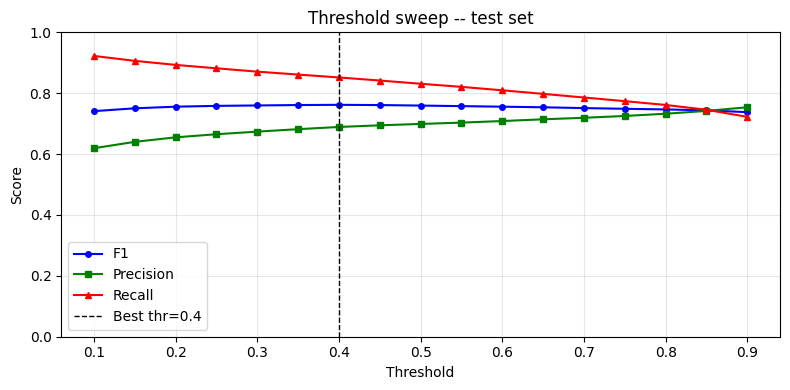

Saved threshold_sweep_test.png


In [40]:
thresholds = np.arange(0.10, 0.95, 0.05)
sweep_rows = []

for thr in thresholds:
    m = FireMetrics()
    for windows in all_fire_results.values():
        for w in windows:
            pred = (w['prob_map'] > thr).astype(bool)
            gt   = w['gt_mask']
            tp = int((pred & gt).sum())
            fp = int((pred & ~gt).sum())
            fn = int((~pred & gt).sum())
            m.tp += tp; m.fp += fp; m.fn += fn
            d = 2*tp + fp + fn
            m.sample_f1s.append(2*tp/d if d > 0 else 0.0)
    sweep_rows.append({
        'threshold': round(float(thr), 2),
        'F1'       : m.F1,
        'Precision': m.precision,
        'Recall'   : m.recall,
        'IoU'      : m.IoU,
    })

df_sweep = pd.DataFrame(sweep_rows)
best_row  = df_sweep.loc[df_sweep['F1'].idxmax()]

print('Threshold sweep results (test set):')
print(f' {"Threshold":>10}  {"F1":>7}  {"Precision":>10}  {"Recall":>8}  {"IoU":>7}')
print('-'*52)
for _, row in df_sweep.iterrows():
    mark = ' <-- best' if row['threshold'] == best_row['threshold'] else ''
    print(f' {row["threshold"]:>10.2f}  {row["F1"]:>7.4f}  '
          f'{row["Precision"]:>10.4f}  {row["Recall"]:>8.4f}  '
          f'{row["IoU"]:>7.4f}{mark}')

print(f'\nBest threshold : {best_row["threshold"]}  (F1={best_row["F1"]:.4f})')

# Plot sweep
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_sweep['threshold'], df_sweep['F1'],        'b-o', ms=4, label='F1')
ax.plot(df_sweep['threshold'], df_sweep['Precision'],  'g-s', ms=4, label='Precision')
ax.plot(df_sweep['threshold'], df_sweep['Recall'],     'r-^', ms=4, label='Recall')
ax.axvline(best_row['threshold'], color='k', ls='--', lw=1, label=f'Best thr={best_row["threshold"]}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Threshold sweep -- test set')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'threshold_sweep_test_v2.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved threshold_sweep_test.png')

## Qualitative visualisation -- 9 panels, paper-style TP/FP/FN colour masks

Each panel shows:
- Background: Band I4 (MIR, 3.7 um) displayed in greyscale -- this is the band most sensitive to active fire heat
- Red overlay  : True Positives  (model correct, fire detected)
- Green overlay: False Positives (model predicts fire, GT says background)
- Blue overlay : False Negatives (model misses fire, GT says fire)

Colour scheme matches the paper Fig 9 exactly.

Plotting 12 fires in a 3x4 grid (9 evaluable, 3 excluded)


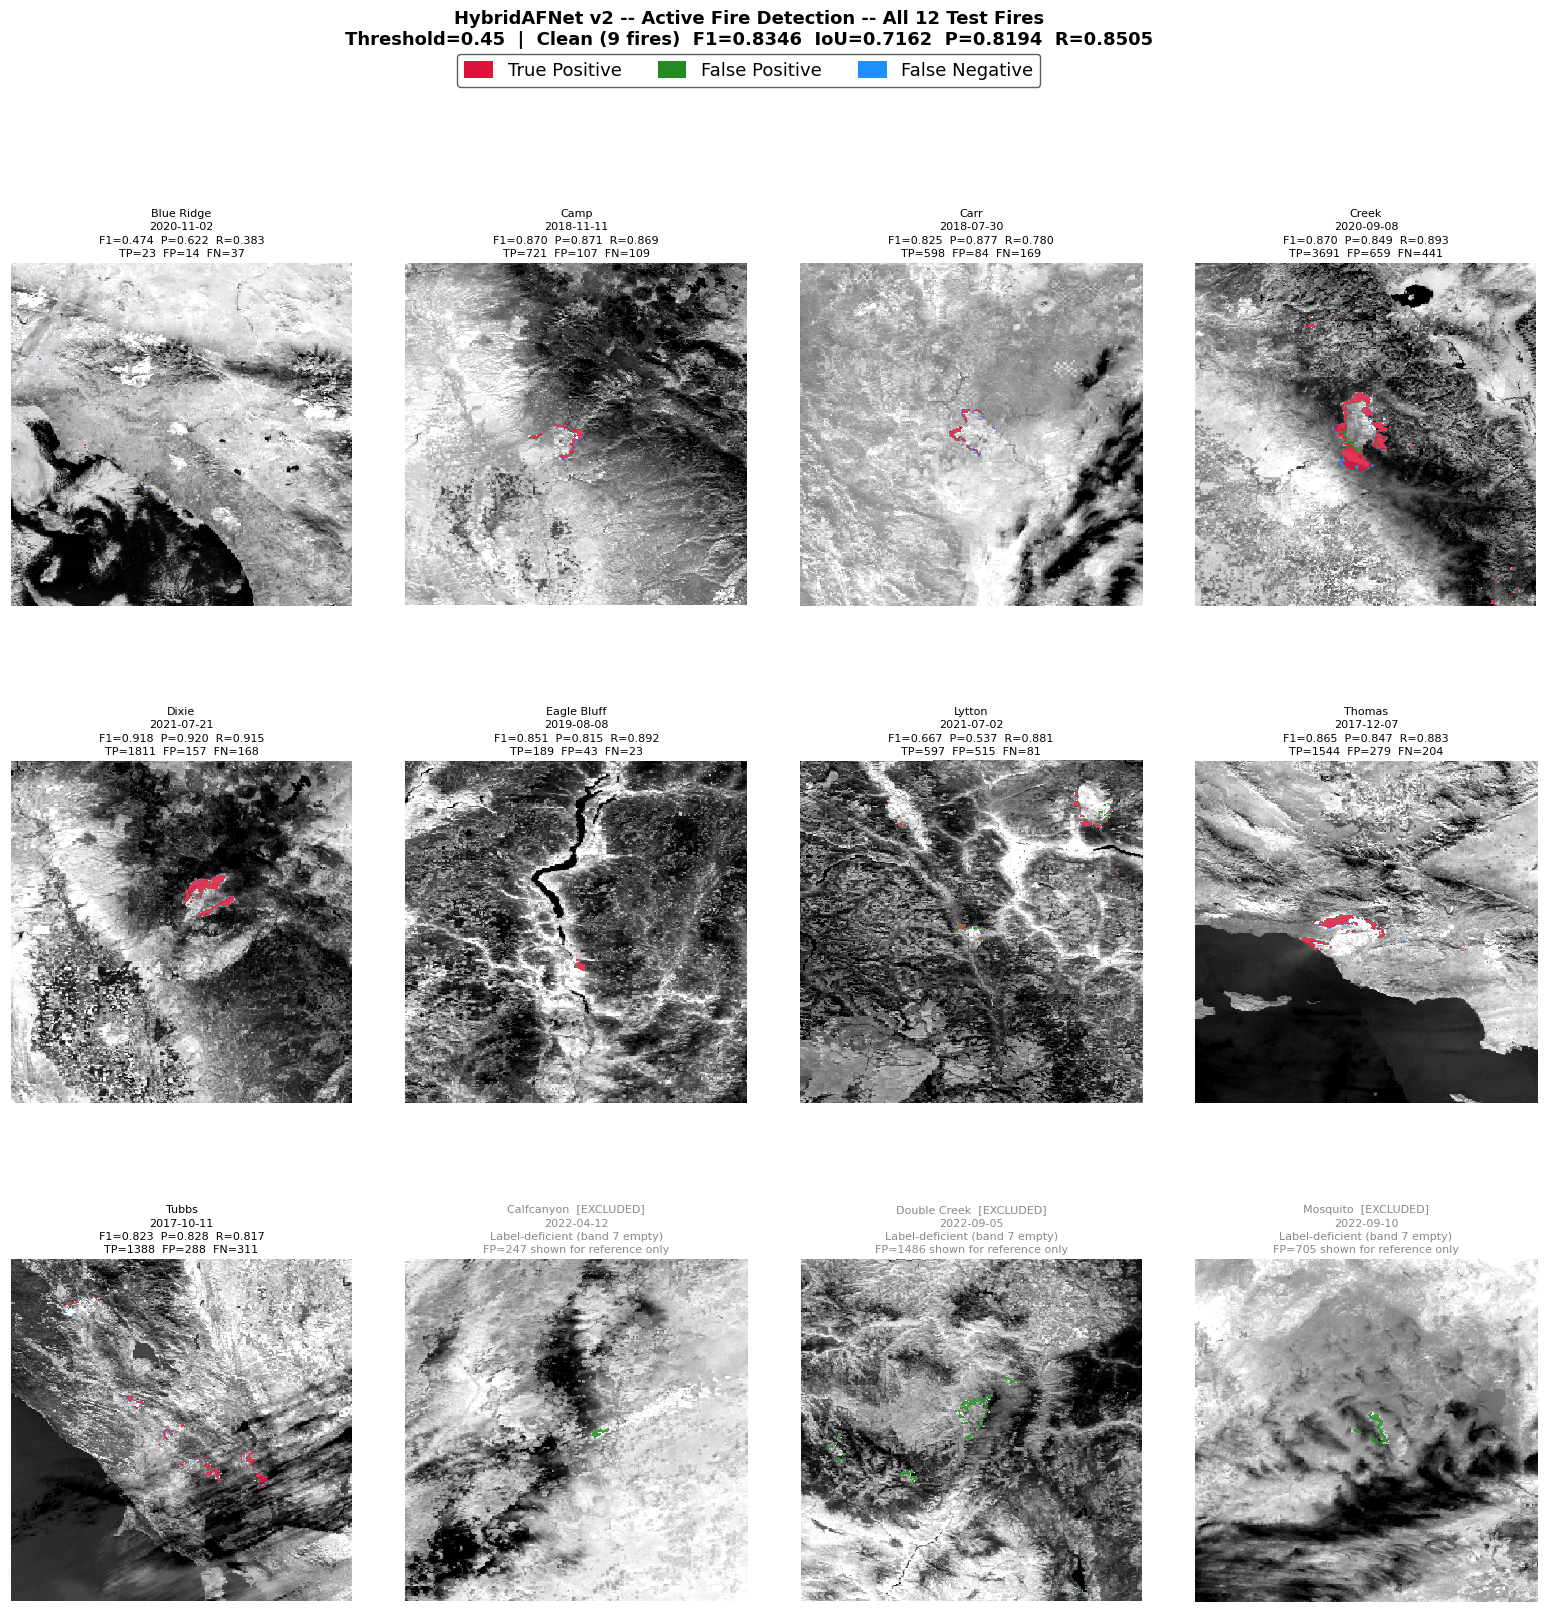

Saved -> /kaggle/working/qual_results_all_fires_v2.png  (12 fires, 3x4 grid)


In [43]:
def make_overlay_rgb(i4_img, pred_mask, gt_mask):
    lo, hi = np.percentile(i4_img[np.isfinite(i4_img)], [2, 98])
    bg  = np.clip((i4_img - lo) / max(hi - lo, 1e-6), 0, 1)
    rgb = np.stack([bg, bg, bg], axis=-1)
    tp_mask = pred_mask &  gt_mask
    fp_mask = pred_mask & ~gt_mask
    fn_mask = ~pred_mask & gt_mask
    alpha = 0.85
    rgb[tp_mask] = (1-alpha)*rgb[tp_mask] + alpha*np.array([220/255,  20/255,  60/255])
    rgb[fp_mask] = (1-alpha)*rgb[fp_mask] + alpha*np.array([ 34/255, 139/255,  34/255])
    rgb[fn_mask] = (1-alpha)*rgb[fn_mask] + alpha*np.array([ 30/255, 144/255, 255/255])
    return np.clip(rgb, 0, 1)


def best_window_per_fire(all_results, evaluable_ids):
    selected = []
    for fid, windows in all_results.items():
        is_evaluable = fid in evaluable_ids

        if is_evaluable:
            # Use gt_has_fire if available, otherwise check gt_mask directly
            gt_windows = [w for w in windows
                          if w.get('gt_has_fire', bool(w['gt_mask'].any()))]
            pool = gt_windows if gt_windows else windows
            best = max(pool, key=lambda w: w['f1'])
        else:
            best = max(windows, key=lambda w: int(w['pred_mask'].sum()))

        selected.append((fid, best, is_evaluable))

    selected.sort(key=lambda x: x[0])
    return selected


# --- Build figure: evaluable fires first, excluded fires last ----------------
samples_eval = [(fid, w, ev) for fid, w, ev in
                best_window_per_fire(all_fire_results, set(evaluable_fire_ids))
                if ev]
samples_excl = [(fid, w, ev) for fid, w, ev in
                best_window_per_fire(all_fire_results, set(evaluable_fire_ids))
                if not ev]
samples = samples_eval + samples_excl

n_fires = len(samples)
N_COLS  = 4
N_ROWS  = math.ceil(n_fires / N_COLS)
print(f'Plotting {n_fires} fires in a {N_ROWS}x{N_COLS} grid '
      f'({len(samples_eval)} evaluable, {len(samples_excl)} excluded)')

fig = plt.figure(figsize=(N_COLS * 5, N_ROWS * 5.8))
gs  = gridspec.GridSpec(N_ROWS, N_COLS, figure=fig, hspace=0.45, wspace=0.08)

for idx, (fid, w, is_evaluable) in enumerate(samples):
    ax  = fig.add_subplot(gs[idx // N_COLS, idx % N_COLS])
    rgb = make_overlay_rgb(w['i4_img'], w['pred_mask'], w['gt_mask'])
    ax.imshow(rgb, interpolation='nearest')

    fire_short = fid.replace('_fire', '').replace('_', ' ').title()
    n_tp = int(w['tp']); n_fp = int(w['fp']); n_fn = int(w['fn'])

    if is_evaluable:
        title_str = (
            f'{fire_short}\n'
            f'{w["date"]}\n'
            f'F1={w["f1"]:.3f}  P={w["precision"]:.3f}  R={w["recall"]:.3f}\n'
            f'TP={n_tp}  FP={n_fp}  FN={n_fn}'
        )
        title_color = 'black'
    else:
        title_str = (
            f'{fire_short}  [EXCLUDED]\n'
            f'{w["date"]}\n'
            f'Label-deficient (band 7 empty)\n'
            f'FP={n_fp} shown for reference only'
        )
        title_color = '#888888'

    ax.set_title(title_str, fontsize=8, pad=4, linespacing=1.4, color=title_color)

    if not is_evaluable:
        for spine in ax.spines.values():
            spine.set_edgecolor('#aaaaaa')
            spine.set_linewidth(2)

    ax.axis('off')

for idx in range(n_fires, N_ROWS * N_COLS):
    fig.add_subplot(gs[idx // N_COLS, idx % N_COLS]).axis('off')

legend_patches = [
    mpatches.Patch(facecolor=(220/255,  20/255,  60/255), label='True Positive'),
    mpatches.Patch(facecolor=( 34/255, 139/255,  34/255), label='False Positive'),
    mpatches.Patch(facecolor=( 30/255, 144/255, 255/255), label='False Negative'),
]
fig.legend(
    handles=legend_patches,
    loc='upper center', ncol=3,
    bbox_to_anchor=(0.5, 1.005),
    fontsize=13, frameon=True, edgecolor='#333',
    handlelength=1.6, handleheight=1.1,
)

fig.suptitle(
    f'HybridAFNet v2 -- Active Fire Detection -- All {n_fires} Test Fires\n'
    f'Threshold={INFER_THRESHOLD}  |  '
    f'Clean ({len(evaluable_fire_ids)} fires)  '
    f'F1={global_metrics_eval.F1:.4f}  IoU={global_metrics_eval.IoU:.4f}  '
    f'P={global_metrics_eval.precision:.4f}  R={global_metrics_eval.recall:.4f}',
    y=1.025, fontsize=13, fontweight='bold'
)

out_path = os.path.join(OUTPUT_DIR, 'qual_results_all_fires_v2.png')
plt.savefig(out_path, dpi=180, bbox_inches='tight')
plt.show()
print(f'Saved -> {out_path}  ({n_fires} fires, {N_ROWS}x{N_COLS} grid)')

## Per-fire results summary table

In [45]:
print('Per-fire results summary:')
print(f'{"Fire ID":<30} {"Windows":>8} {"F1":>7} {"IoU":>7} {"Prec":>7} {"Rec":>7}')
print('-' * 72)
for _, row in df_fires.iterrows():
    print(f'{row["fire_id"]:<30} {row["n_windows"]:>8.0f} '
          f'{row["f1"]:>7.4f} {row["iou"]:>7.4f} '
          f'{row["precision"]:>7.4f} {row["recall"]:>7.4f}')
print('-' * 72)
print(f'{"AGGREGATE":<30} {"":>8} '
      f'{global_metrics.F1:>7.4f} {global_metrics.IoU:>7.4f} '
      f'{global_metrics.precision:>7.4f} {global_metrics.recall:>7.4f}')
print()

# Comparison table
print('Comparison with paper baselines (AF test set F1):')
print(f'{"Model":<22} {"F1":>7}  {"IoU":>7}  {"Params":>10}')
print('-' * 52)
baselines = [
    ('U-Net 2D',      0.731, 0.605, '10.6M'),
    ('GRU-3',         0.713, 0.601, '64.3K'),
    ('LSTM-3',        0.765, 0.654, '84.9K'),
    ('T4Fire',        0.802, 0.700, '32.5K'),
    ('U-Net-3D',      0.748, 0.628, '31.7M'),
    ('UNETR-3D',      0.811, 0.706, '34.8M'),
    ('SwinUNETR-3D',  0.797, 0.688, '33.2M'),
]
n_params = sum(p.numel() for p in model.parameters())
for name, f1, iou, params in baselines:
    print(f'{name:<22} {f1:>7.3f}  {iou:>7.3f}  {params:>10}')
print(f'{"HybridAFNet v2 (ours)":<22} '
      f'{global_metrics.F1:>7.3f}  {global_metrics.IoU:>7.3f}  '
      f'{n_params/1e6:>9.2f}M'  )
print('-' * 52)

Per-fire results summary:
Fire ID                         Windows      F1     IoU    Prec     Rec
------------------------------------------------------------------------
dixie_fire                            2  0.9139  0.8415  0.9116  0.9163
creek_fire                            2  0.8572  0.7501  0.8395  0.8757
eagle_bluff_fire                      2  0.8514  0.7412  0.8147  0.8915
thomas_fire                           2  0.8508  0.7403  0.8340  0.8683
camp_fire                             2  0.8419  0.7269  0.8434  0.8404
tubbs_fire                            2  0.8074  0.6770  0.8328  0.7835
carr_fire                             2  0.7795  0.6387  0.8776  0.7011
lytton_fire                           2  0.6643  0.4974  0.5637  0.8087
blue_ridge_fire                       2  0.4670  0.3046  0.5699  0.3955
calfcanyon_fire                       2  0.0000  0.0000  0.0000  0.0000
double_creek_fire                     2  0.0000  0.0000  0.0000  0.0000
mosquito_fire                        

## Save all outputs

In [46]:
# Save aggregate metrics to JSON
results_json = {
    'model'            : 'HybridAFNet_v2',
    'eval_set'         : eval_label,
    'n_fires'          : len(eval_fires),
    'threshold'        : INFER_THRESHOLD,
    'F1'               : round(global_metrics.F1, 6),
    'IoU'              : round(global_metrics.IoU, 6),
    'precision'        : round(global_metrics.precision, 6),
    'recall'           : round(global_metrics.recall, 6),
    'mF1'              : round(global_metrics.mF1, 6),
    'TP'               : global_metrics.tp,
    'FP'               : global_metrics.fp,
    'FN'               : global_metrics.fn,
    'best_threshold'   : float(best_row['threshold']),
    'best_threshold_F1': round(float(best_row['F1']), 6),
}
results_path = os.path.join(OUTPUT_DIR, 'test_results_af_v2.json')
with open(results_path, 'w') as f:
    json.dump(results_json, f, indent=2)

output_files = [
    'test_results_af_v2.json',
    'per_fire_metrics_v2.csv',
    'qual_results_all_fires_v2.png',
    'threshold_sweep_test_v2.png',
]

print('Saved files:')
for fname in output_files:
    fpath = os.path.join(OUTPUT_DIR, fname)
    if os.path.exists(fpath):
        size_kb = os.path.getsize(fpath) // 1024
        print(f'  {fname:<45}  {size_kb:>5} KB')
    else:
        print(f'  {fname:<45}  NOT FOUND')

# Zip
zip_path = os.path.join(OUTPUT_DIR, 'af_hybrid_v2_inference_outputs.zip')
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in output_files:
        fpath = os.path.join(OUTPUT_DIR, fname)
        if os.path.exists(fpath):
            zf.write(fpath, fname)
print(f'\nZipped to: {zip_path}')

print()
print('=' * 55)
print('FINAL TEST RESULT  -- HybridAFNet v2')
print(f'  F1        : {global_metrics.F1:.4f}')
print(f'  IoU       : {global_metrics.IoU:.4f}')
print(f'  Precision : {global_metrics.precision:.4f}')
print(f'  Recall    : {global_metrics.recall:.4f}')
print(f'  mF1       : {global_metrics.mF1:.4f}')
print('=' * 55)


Saved files:
  test_results_af_v2.json                            0 KB
  per_fire_metrics_v2.csv                            1 KB
  qual_results_all_fires_v2.png                   3418 KB
  threshold_sweep_test_v2.png                       44 KB

Zipped to: /kaggle/working/af_hybrid_v2_inference_outputs.zip

FINAL TEST RESULT  -- HybridAFNet v2
  F1        : 0.7611
  IoU       : 0.6143
  Precision : 0.6946
  Recall    : 0.8416
  mF1       : 0.5459
